In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BastmanState(TypedDict):
    runs: int 
    balls: int 
    fours: int 
    sixes: int 
    strike_rate: float
    bpb: float
    boundary_percent: float
    summary: str

In [3]:
# Create a graph which gonna be class of StateGraph 
graph = StateGraph(BastmanState)

In [4]:
def calculate_strike_rate(state: BastmanState)-> BastmanState: 
    # Get the runs and balls from state 
    runs = state['runs']
    balls = state['balls']
    # Calculate the strike rate 
    strike_rate = (runs / balls) * 100 if balls > 0 else 0.0
    
    # Update the strike rate in state and return it 
    return {'strike_rate': strike_rate}


def calculate_bpb(state: BastmanState) -> BastmanState:
    # Get the runs and balls from state
    fours = state['fours']
    sixes = state['sixes']
    balls = state['balls']
    
    # Calculate the bpb (balls per boundary))
    total_boundaries = fours + sixes
    bpb = (balls / total_boundaries) if total_boundaries > 0 else float('inf')
    
    # Update the bpb in state and return it  
    return {'bpb': bpb}


def calculate_bp(state: BastmanState) -> BastmanState:
    # Get the runs and balls from state 
    runs = state['runs']
    balls = state['balls']
    fours = state['fours']
    sixes = state['sixes']
    
    # Calculate the boundary percentage 
    total_runs_from_boundaries = (fours * 4) + (sixes * 6)
    boundary_percent = (total_runs_from_boundaries / runs) * 100 if runs > 0 else 0.0
    
    # Update the boundary percentage in state and return it 
    return {'boundary_percent': boundary_percent}


def summary(state: BastmanState) -> BastmanState: 
    
    summary = f"""
    Strike Rate: {state['strike_rate']:.2f} \n 
    Balls per Boundary: {state['bpb']:.2f} \n 
    Boundary Percentage: {state['boundary_percent']:.2f}
    
    """
    
    return {'summary': summary}

In [5]:
graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calcuate_bp', calculate_bp)
graph.add_node('summary', summary)


# Add edges 
graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calcuate_bp')

graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calcuate_bp', 'summary')

graph.add_edge('summary', END)


workflow = graph.compile()

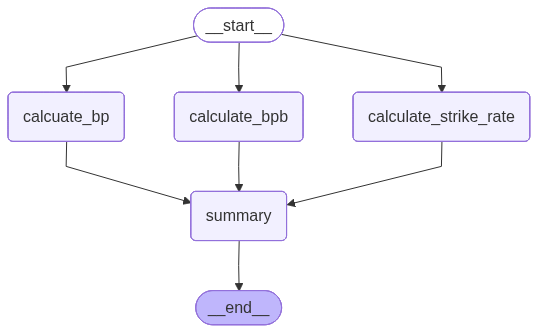

In [6]:
workflow

In [7]:
inital_state = {
    'runs': 150,
    'balls': 120,
    'fours': 10,
    'sixes': 5
}

workflow.invoke(inital_state)

{'runs': 150,
 'balls': 120,
 'fours': 10,
 'sixes': 5,
 'strike_rate': 125.0,
 'bpb': 8.0,
 'boundary_percent': 46.666666666666664,
 'summary': '\n    Strike Rate: 125.00 \n \n    Balls per Boundary: 8.00 \n \n    Boundary Percentage: 46.67\n    \n    '}